In [1]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join
import os
import seaborn as sns

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir, google_folder_id, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

Added to sys: d:\GMM 4\Reading seminar\Projet-recheche-INSA-anomaly-detection-librairy\src


# Goal

- Perform PCA reconstruction using the threshold for each sensor

# PCA Space construction

In [2]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

Extracted data found at: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24
Loading ARAG data from: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24


In [3]:
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

In [4]:
len(list_session)

40

## Function to create whole dataset

In [5]:
import random

def create_session_anomaly(data_dict, session_anomaly):
    """
    Create a list of anomalous session path
    """
    list_keys = list(data_dict.keys())

    # Find the list of anomalous session path
    session_anomaly_list = []
    for s in list_keys:
        df = data_dict[s].copy()
        if preprocessing.clean_dataframe(df).shape[0] != 0 and os.path.splitext(os.path.basename(s))[0] in session_anomaly:
            session_anomaly_list.append(s)
    
    return session_anomaly_list

def create_session_clean(data_dict, session_anomaly):
    """
    Create a list of clean session path
    """
    list_keys = list(data_dict.keys())

    # Find the list of clean session path
    session_clean = []
    for s in list_keys:
        df = data_dict[s].copy()
        if preprocessing.clean_dataframe(df).shape[0] != 0 and os.path.splitext(os.path.basename(s))[0] not in session_anomaly:
            session_clean.append(s)
    
    return session_clean


def split_session(session_clean, p=2/3, seed = None):
    """
    split the list of clean session path into train and test
    """
    if seed is not None:
        random.seed(seed)
    sessions = session_clean.copy()
    random.shuffle(sessions)
    n_train = int(len(sessions) * p)
    session_train = sessions[:n_train]
    session_test = sessions[n_train:]
    return session_train, session_test

def merge_dataset(data_dict, session):
    """ 
    Preprocess the session in the list session and concatenate to a single dataset
    """
    temp_list = []
    for s in session:
        df = data_dict[s].copy()
        df = preprocessing.clean_dataframe(df)
        df['session_id'] = os.path.splitext(os.path.basename(s))[0]
        temp_list.append(df)

    df_train = pd.concat(temp_list, ignore_index=True)
    return df_train

def create_dataset(data_dict, session_anomaly, split=False, p=2/3, seed=423):
    """
    Create the whole preprocessed dataset and remove the anomalous sessions. 

    data_dict (dict): The dictionnary containing all data
    session_anomaly (list): List of name of anomalous sessions
    split (bool): If True, split the dataset to train and test dataset
    p (int, 0<p<1): Ratio train/test
    seed (int): random seed for the split

    Return : 
    if split is False, return whole dataset and the session path list
    if split is True, return train dataset, test dataset and their session path list

    """
    #Create session clean list
    session_clean = create_session_clean(data_dict, session_anomaly)

    # if split is False, we will prerpocess all data
    session_train = session_clean 
    
    # Create train data session path list and test data session path list
    if split :
        session_train, session_test = split_session(session_clean, p, seed)
    
    # Create train dataset
    df_train = merge_dataset(data_dict, session_train)

    # Create test dataset
    if split:
        df_test = merge_dataset(data_dict, session_test)
        return df_train, df_test, session_train, session_test
        
    return df_train, session_train


In [6]:
# example of creating train dataset and test dataset
session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']
df_all, df_all_test, list_train, list_test= create_dataset(data_dict, session_anomaly,split=True, seed=423)
cols = [c for c in df_all.columns if c not in ['session_id', 'time_real', 'datetime', ]]

In [7]:
list_test_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in list_test
]
np.array(list_test_names)

array(['T24S12-04_E-AL3358', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3479',
       'T24S12-04_E-AL3499', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3538',
       'T24S12-04_E-AL3438', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3014',
       'T24S12-04_E-AL3221'], dtype='<U18')

In [8]:
list_train_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in list_train
]
np.array(list_train_names)

array(['T24S12-04_E-AL3458', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL3577',
       'T24S12-04_E-AL3070', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2870',
       'T24S12-04_E-AL3417', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671',
       'T24S12-04_E-AL2889', 'T24S12-04_E-AL3143', 'T24S12-04_E-AL2987',
       'T24S12-04_E-AL3339', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3240',
       'T24S12-04_E-AL3319', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3690',
       'T24S12-04_E-AL3033', 'T24S12-04_E-AL3280'], dtype='<U18')

## Train data and test data

In [9]:
# Using the result of anl02p1, PCA

session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

In [10]:
# Create a list of clean session path

session_clean = create_session_clean(data_dict, session_anomaly)
session_clean_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_clean
]
np.array(session_clean_names)

array(['T24S12-04_E-AL2870', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL2909',
       'T24S12-04_E-AL2928', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014',
       'T24S12-04_E-AL3033', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3070',
       'T24S12-04_E-AL3143', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240',
       'T24S12-04_E-AL3261', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3319',
       'T24S12-04_E-AL3339', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL3377',
       'T24S12-04_E-AL3397', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438',
       'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499',
       'T24S12-04_E-AL3538', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577',
       'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3690'],
      dtype='<U18')

In [11]:
import random

seed = 423

session_train, session_test= split_session(session_clean, seed = seed)
print(len(session_train), len(session_test))

20 10


In [12]:
session_test_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_test
]
np.array(session_test_names)

array(['T24S12-04_E-AL3358', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3479',
       'T24S12-04_E-AL3499', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3538',
       'T24S12-04_E-AL3438', 'T24S12-04_E-AL3377', 'T24S12-04_E-AL3014',
       'T24S12-04_E-AL3221'], dtype='<U18')

In [13]:
session_train_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_train
]
np.array(session_train_names)

array(['T24S12-04_E-AL3458', 'T24S12-04_E-AL2928', 'T24S12-04_E-AL3577',
       'T24S12-04_E-AL3070', 'T24S12-04_E-AL2909', 'T24S12-04_E-AL2870',
       'T24S12-04_E-AL3417', 'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671',
       'T24S12-04_E-AL2889', 'T24S12-04_E-AL3143', 'T24S12-04_E-AL2987',
       'T24S12-04_E-AL3339', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3240',
       'T24S12-04_E-AL3319', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3690',
       'T24S12-04_E-AL3033', 'T24S12-04_E-AL3280'], dtype='<U18')

## Dataset

### PCA

In [14]:
from sklearn.neighbors import LocalOutlierFactor
def replace_outliers_moving_average(df, cols, outlier_mask, window=20):
    """
    Replace LOF outliers using moving average interpolation.

    Parameters
    ----------
    df : pandas DataFrame
    cols : columns to clean
    outlier_mask : boolean array (True = outlier)
    window : moving average window size

    Returns
    -------
    df_clean : cleaned dataframe
    """

    df_clean = df.copy()

    for col in cols:

        # compute rolling mean
        rolling_mean = df_clean[col].rolling(window=window, center=True, min_periods=1).mean()

        # replace outliers
        df_clean.loc[outlier_mask, col] = rolling_mean[outlier_mask]

    return df_clean

In [15]:
# Train PCA of standardized data

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from anomaly_detection.dimension_reduction.pca import dynamic_augmentation, inverse_dynamic_augmentation, lag_augmented
from scipy.stats import chi2
from anomaly_detection.dimension_reduction.kpca import MultiGKPCA

scaler = StandardScaler()
pca = PCA()
ncp = 3
lag = 8

In [16]:
temp_list = []

for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        if s == session_train[7]:
            df = df.iloc[:9200,:]
        temp_list.append(df)

df_train = pd.concat(temp_list, ignore_index=True)
scaler = StandardScaler()
pca = PCA()
respca = pca.fit_transform(scaler.fit_transform(df_train[cols]))
respca[:,ncp:] = 0
df_train_inv = pca.inverse_transform(respca)

In [19]:
erreurs_par_capteur = np.abs(scaler.transform(df_train[cols]) - df_train_inv)
mu = np.mean(erreurs_par_capteur, axis=0)
sigma = np.std(erreurs_par_capteur, axis=0)
BETA = 3
seuils_dynamiques = mu + BETA * sigma

# Analysis on test data

## Functions

In [48]:
def visualisation_plot(df, cols):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_anomalies(df, anomaly_mask, cols):
    """
    Visualize anomalies on the original signal

    Parameters
    ----------
    df : pandas DataFrame
        The original dataframe containing the signals and time
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    cols : list of str
        The list of columns to visualize

    Returns
    -------
    None
    """
    # Visualize anomalies
    dff = df.copy()
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
    axes = axes.flatten()

    for ax, col in zip(axes, cols[:nrows * ncols]):

        # original signal plot
        visualisation.plot(dff, 'time_real', col, ax=ax)

        # overlay anomaly points
        ax.scatter(
            dff.loc[anomaly_mask[:,cols.index(col)], 'time_real'],
            dff.loc[anomaly_mask[:,cols.index(col)], col],
            color='red',
            s=10,
            label='SPE anomaly',
            zorder=3
        )

        ax.legend(loc="upper right", fontsize=8)

    # hide unused axes
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

def pca_anomaly_detection(df, PCA, SCALER, seuil=None, d=3):
    """
    Apply PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    PCA : PCA object
        The trained PCA model
    SCALER : StandardScaler object
        The trained scaler used for PCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 3.

    Returns
    -------
    anomaly_mask : boolean matrix
        A boolean matrix where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    res_pca = PCA.transform(df_center)
    res_pca[:,d:] = 0
    df_inv = PCA.inverse_transform(res_pca)
    SPE = np.abs((df_center - df_inv)**2)
    anomaly_mask = SPE > seuil
    return anomaly_mask

## PCA

### SPE

In [49]:
# Projection on PCA space of the 8th session_test

df = data_dict[session_test[8]].copy()
df = preprocessing.clean_dataframe(df)

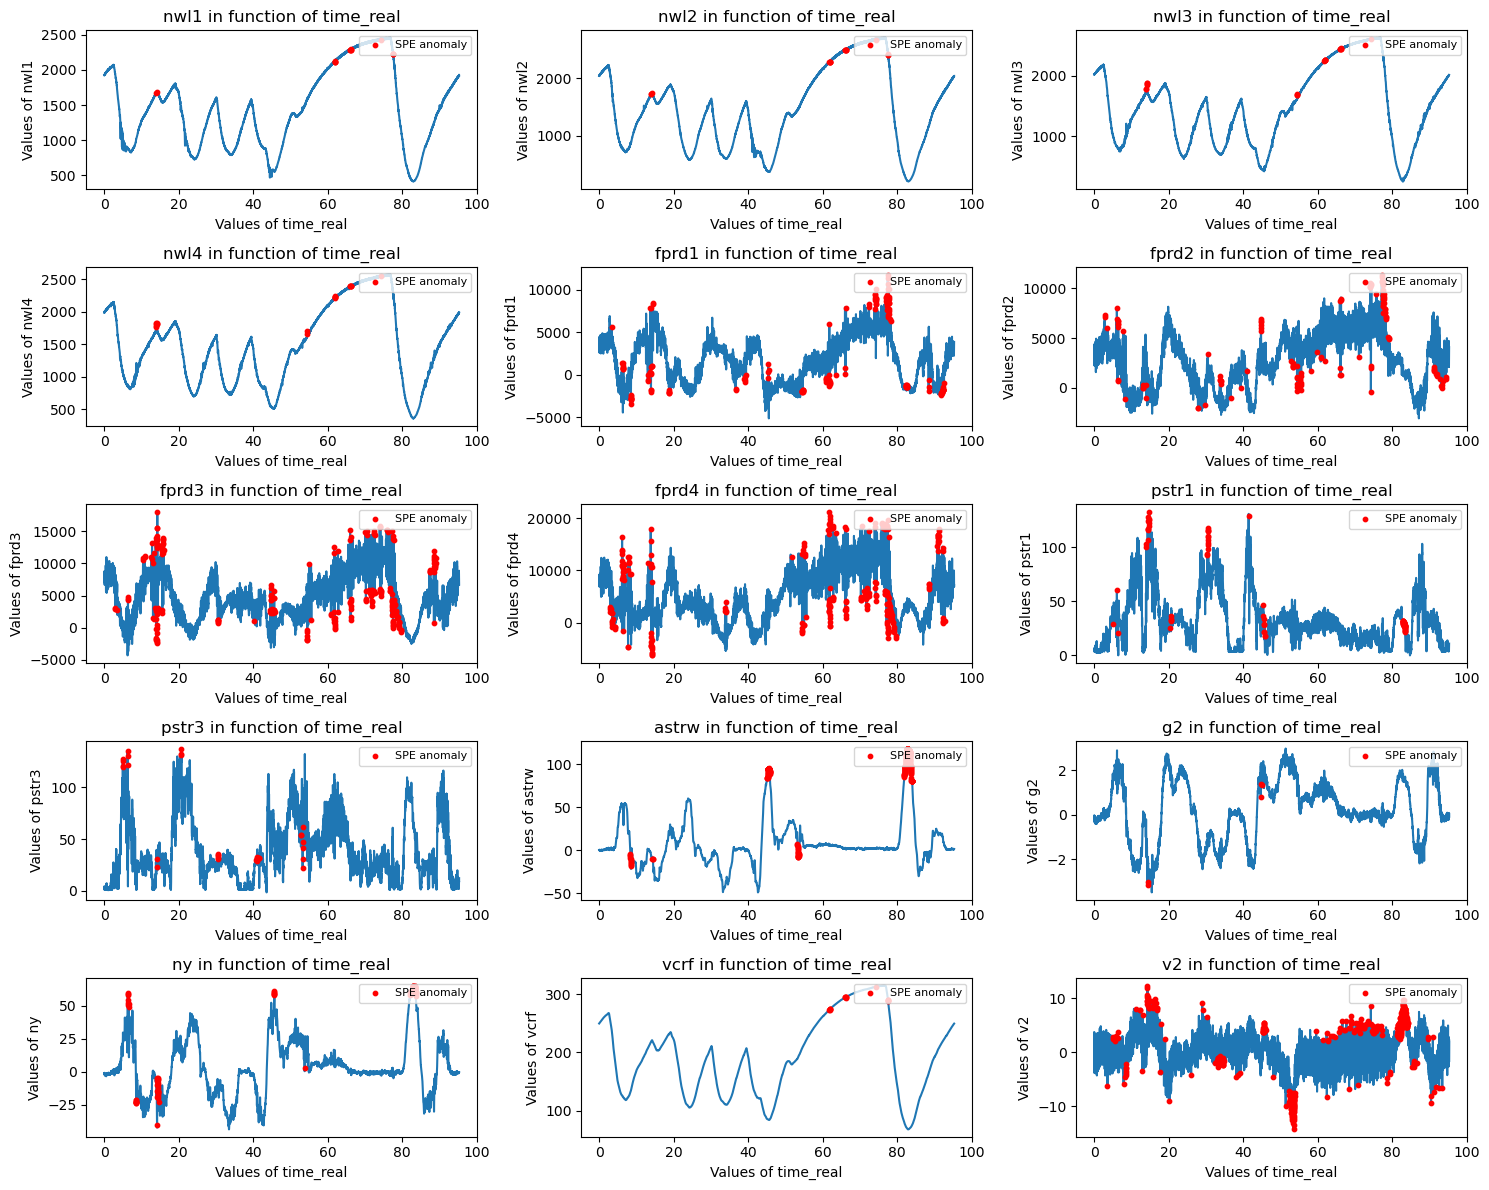

In [51]:
# Visualize anomalies

anomaly_mask = pca_anomaly_detection(df[cols], pca, scaler, seuils_dynamiques, d=ncp)
visualisation_anomalies(df, anomaly_mask, cols)


# Test on anomalous sessions

In [52]:
session_anomaly_test = create_session_anomaly(data_dict, session_anomaly)
len(session_anomaly_test)

10

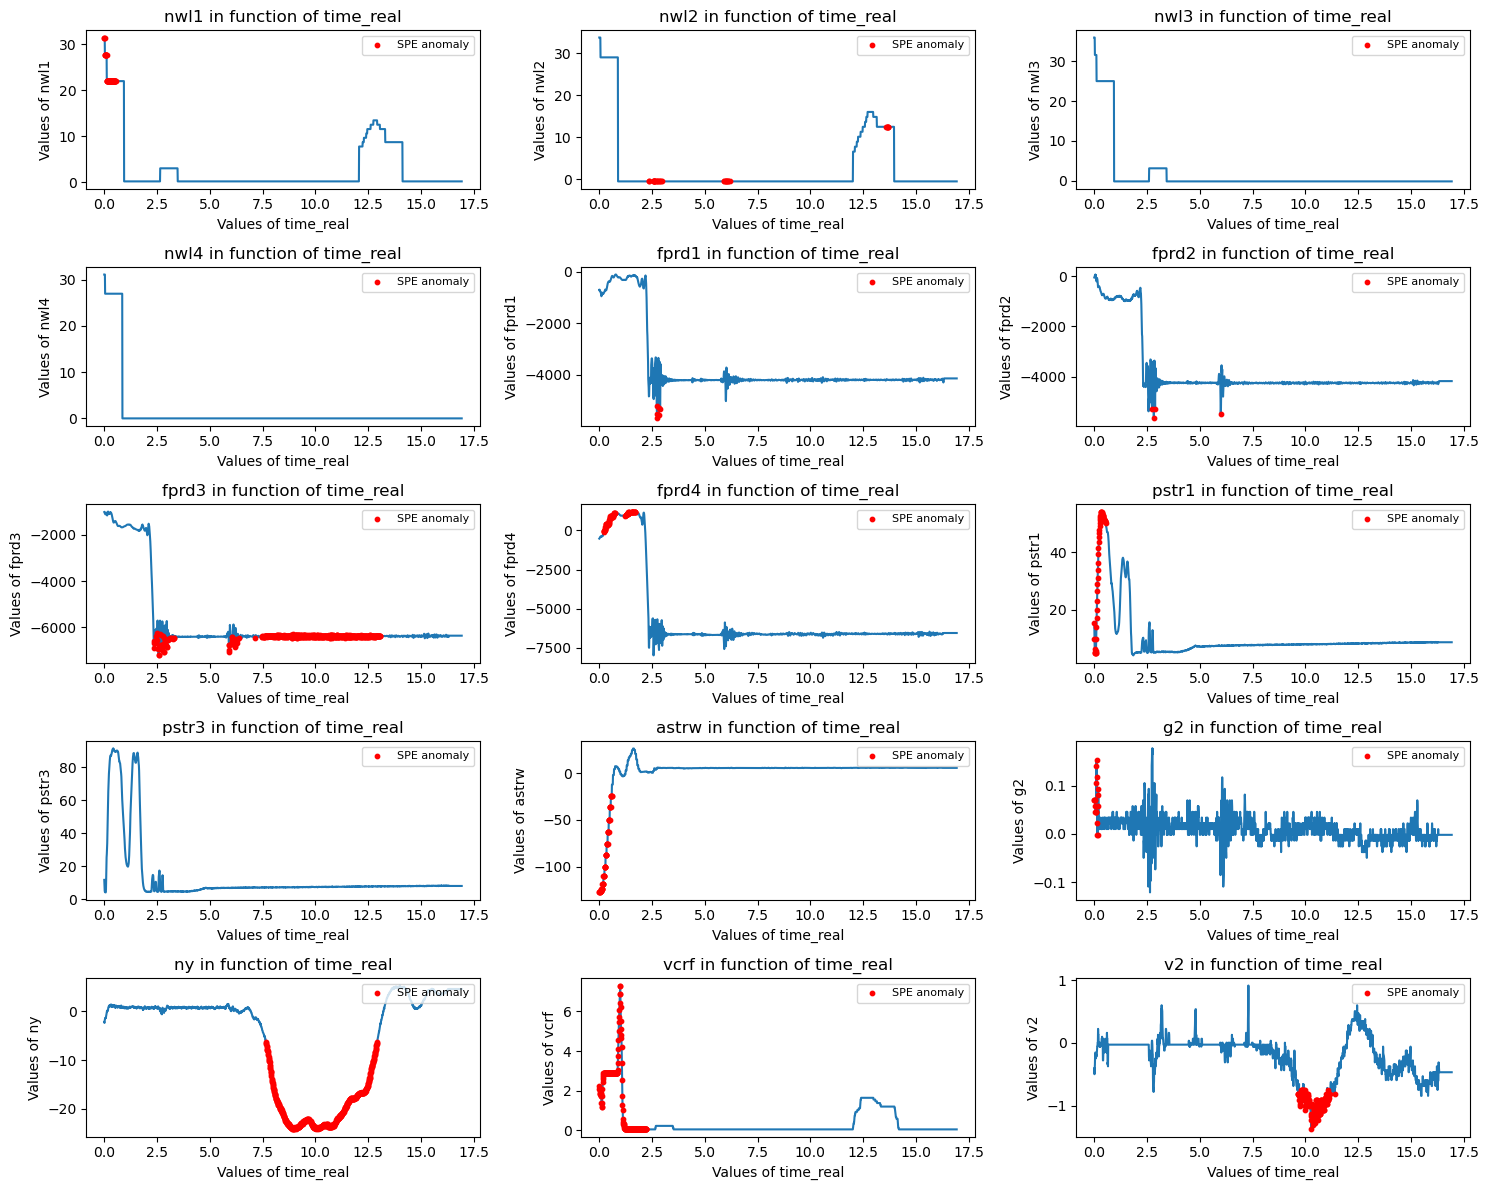

In [55]:
df_test = data_dict[session_anomaly_test[1]].copy()
df_test = preprocessing.clean_dataframe(df_test)
anomaly_mask = pca_anomaly_detection(df_test[cols], pca, scaler, seuils_dynamiques, d=ncp)
visualisation_anomalies(df_test, anomaly_mask, cols)